# Imports

In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

import pvlib

import seaborn as sns
import warnings
import math
import pickle
from numpy.random import seed

from IPython.display import display

from sklearn import tree
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn import metrics
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import make_scorer, mean_squared_error, r2_score

import scipy
from scipy.cluster import hierarchy as hc

warnings.filterwarnings('ignore')

## Reading and preparing data

In [2]:
df = pd.read_csv('spg.csv', low_memory=False)

In [3]:
#dropping features we won't have data of
no_data = ["mean_sea_level_pressure_MSL", "wind_speed_900_mb", "wind_direction_900_mb"]
df = df.drop(no_data, axis = 1)

In [4]:
#renaming columns
df = df.rename(columns={
    "temperature_2_m_above_gnd"          : "temperature_2m",
    "relative_humidity_2_m_above_gnd"    : "relative_humidity_2m",
    "total_precipitation_sfc"            : 'precipitation',
    "snowfall_amount_sfc"                : 'snowfall',
    "total_cloud_cover_sfc"              : 'cloud_cover',
    "high_cloud_cover_high_cld_lay"      : 'cloud_cover_high',
    "medium_cloud_cover_mid_cld_lay"     : 'cloud_cover_mid',
    "low_cloud_cover_low_cld_lay"        : 'cloud_cover_low',
    "shortwave_radiation_backwards_sfc"  : 'shortwave_radiation_instant',
    "wind_speed_10_m_above_gnd"          : 'wind_speed_10m',
    "wind_direction_10_m_above_gnd"      : 'wind_direction_10m',
    "wind_speed_80_m_above_gnd"          : 'wind_speed_80m',
    "wind_direction_80_m_above_gnd"      : 'wind_direction_80m',
    "wind_gust_10_m_above_gnd"           : 'wind_gusts_10m'
})

# Training

## Raw Data vs Normalized Data

In [5]:
def normalize(df):
    df_new = df.copy()
    normalization_keys = {}
    for key in df_new.keys():
        x = df[key]
        a = min(x)
        b = max(x)
        df_new[key] = (x-a)/(b-a)
        normalization_keys[key] = {
            "min" : a,
            "max" : b
        }
    return df_new, normalization_keys

def denormalize_array(arr, normalization_key):
    a = normalization_key["min"]
    b = normalization_key["max"]
    return (b-a)*arr+a

def denormalize(df, normalization_keys, column = None):
    df_new = df.copy()
    if column:
        df_new = denormalize_array(df_new, normalization_keys[column])
    else:
        for key in df_new.keys():
            df_new[key] = denormalize_array(df[key], normalization_keys[key])
    return df_new

In [6]:
y_column = "generated_power_kw"

# raw data
X_raw = df.drop(y_column, axis = 1)
y_raw = df[y_column]

# normalized data
df_n, nkeys = normalize(df)
X_nor = df_n.drop(y_column, axis = 1)
y_nor = df_n[y_column]

In [7]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.20, random_state=42)

X_train_nor, X_test_nor, y_train_nor, y_test_nor = train_test_split(X_nor, y_nor, test_size=0.20, random_state=42)

In [8]:
def rmse(x,y): return math.sqrt(((x-y)**2).mean())

def print_score_(m, X_train, y_train, X_test, y_test):
    res = {'rmse_train': rmse(m.predict(X_train), y_train), 'rmse_test': rmse(m.predict(X_test), y_test), 'r2_train': m.score(X_train, y_train), 'r2_test': m.score(X_test, y_test)}
    if hasattr(m, 'oob_score_'): res['r2_oob'] = m.oob_score_
    print(res)

def print_score_raw(m):
    print_score_(m, X_train_raw, y_train_raw, X_test_raw, y_test_raw)

def print_score_nor(m):
    print_score_(m, X_train_nor, y_train_nor, X_test_nor, y_test_nor)

In [9]:
n_trees = 75
m_raw = RandomForestRegressor(n_jobs=-1, n_estimators=n_trees, oob_score=True)
m_nor = RandomForestRegressor(n_jobs=-1, n_estimators=n_trees, oob_score=True)

In [10]:
%time m_raw.fit(X_train_raw, y_train_raw)
m_raw.score(X_train_raw, y_train_raw)

CPU times: user 2.16 s, sys: 82.1 ms, total: 2.24 s
Wall time: 264 ms


0.9695393503704065

In [11]:
%time m_nor.fit(X_train_nor, y_train_nor)
m_nor.score(X_train_nor, y_train_nor)

CPU times: user 2.17 s, sys: 61.6 ms, total: 2.23 s
Wall time: 276 ms


0.9700225768832581

In [12]:
print_score_raw(m_raw)

{'rmse_train': 162.8881901889768, 'rmse_test': 418.7449612936041, 'r2_train': 0.9695393503704065, 'r2_test': 0.8080412721720032, 'r2_oob': 0.7792502128745844}


In [13]:
print_score_nor(m_nor)

{'rmse_train': 0.05286290974363438, 'rmse_test': 0.1354425543083681, 'r2_train': 0.9700225768832581, 'r2_test': 0.8123488849797068, 'r2_oob': 0.7832052950444524}


The normalized data performs slightly better, but not by much

The model performs significantly better on the data it's trained on than on the test-dataset and the out-of-bag score, meaning that it's likely overfitted

We'll continue with the normalized data:

In [14]:
X = X_nor
y = y_nor
X_train = X_train_nor
y_train = y_train_nor
X_test = X_test_nor
y_test = y_test_nor
m = m_nor

def print_score(m):
    print_score_(m, X_train, y_train, X_test, y_test)

## Optimalisation

In [15]:
preds = np.stack([t.predict(X_test) for t in m.estimators_])

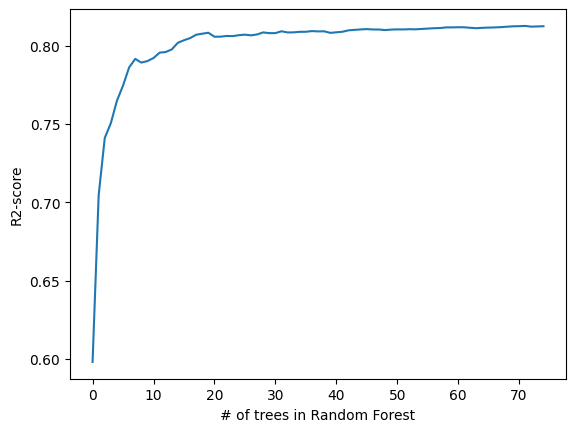

In [16]:
fig = plt.figure()
plt.plot([metrics.r2_score(y_test, np.mean(preds[:i+1], axis=0)) for i in range(n_trees)]);
plt.xlabel("# of trees in Random Forest")
plt.ylabel("R2-score")
plt.show()

Adding more trees to the forest isn't gonna significantly imporve our model

In [17]:
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)
r2_scorer = make_scorer(lambda y_true, y_pred: r2_score(y_true, y_pred))
scoring = {
    "rmse" : rmse_scorer,
    "r2" : r2_scorer
}

In [18]:
parameters = {'min_samples_leaf':[3, 5, 10],
              'max_features': ['None', 0.5, 'log2', 'sqrt'],
              'max_depth' : [2, 3, 5, 10]
             }
RF_model = RandomForestRegressor(n_jobs=-1, random_state=42, oob_score=True, n_estimators = n_trees)
grid_search = GridSearchCV(RF_model, parameters)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print(best_params)

{'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 3}


In [19]:
m = grid_search.best_estimator_

In [20]:
print_score(m)

{'rmse_train': 0.09488097329954955, 'rmse_test': 0.13540726994197155, 'r2_train': 0.9034281766796419, 'r2_test': 0.8124466428562823, 'r2_oob': 0.7816498613294215}


In [21]:
feature_importances = m.feature_importances_
index_len = len(feature_importances) + 1
feature_names = X.columns

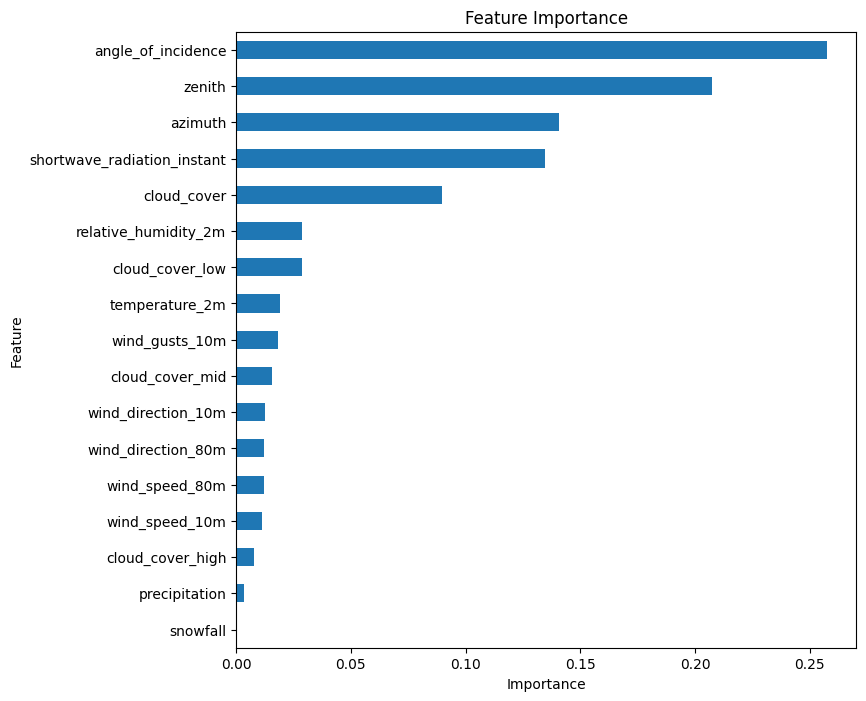

In [24]:
feature_importances = pd.Series(feature_importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
feature_importances.plot(kind='barh').invert_yaxis() # Show only top 30, displayed transposed
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [25]:
def filter_important_features(model, df, threshold=0.005):
    feature_importances = pd.Series(model.feature_importances_, index=df.columns).sort_values(ascending=False)
    to_keep = feature_importances[feature_importances > threshold].index  # Use 'index' to get column names
    return list(to_keep)

In [27]:
to_keep = filter_important_features(m, X, threshold=0.05)
X_keep = X[to_keep].copy()
X_train_keep, X_test_keep, y_train_keep, y_test_keep = train_test_split(X_keep, y, test_size=0.20, random_state=42)

In [32]:
m_keep = RandomForestRegressor(n_jobs=-1, n_estimators=n_trees, oob_score=True, max_depth = 10, max_features = 0.5, min_samples_leaf = 3)

In [33]:
%time m_keep.fit(X_train_keep, y_train_keep)
m_keep.score(X_train_keep, y_train_keep)

CPU times: user 305 ms, sys: 58.6 ms, total: 363 ms
Wall time: 162 ms


0.8632586190323595

In [34]:
print_score_(m_keep, X_train_keep, y_train_keep, X_test_keep, y_test_keep)

{'rmse_train': 0.11290258778545818, 'rmse_test': 0.14559005734455022, 'r2_train': 0.8632586190323595, 'r2_test': 0.7831775175461395, 'r2_oob': 0.7539491631971528}


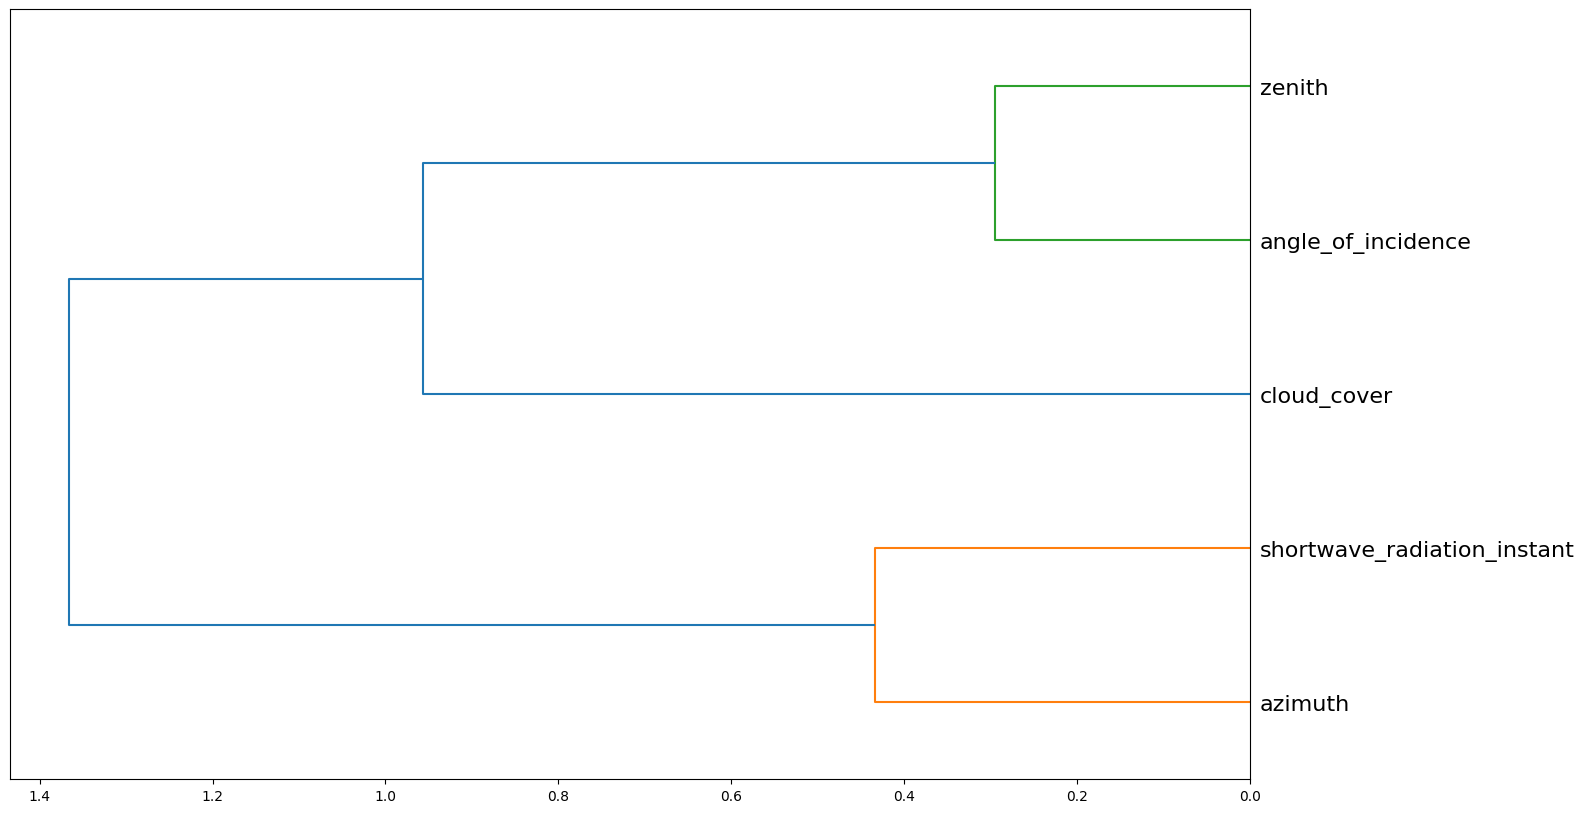

In [39]:
corr = np.round(scipy.stats.spearmanr(X_keep).correlation, 4)
corr_condensed = hc.distance.squareform(1-corr)
z = hc.linkage(corr_condensed, method='average')
fig = plt.figure(figsize=(16,10))
dendrogram = hc.dendrogram(z, labels=X_keep.columns, orientation='left', leaf_font_size=16)
plt.show()